# Unsupervised Clustering for Plant Health
### AI for Plant Pathologists

In **supervised** learning you already have labels (e.g. *healthy* vs *diseased*) and teach a
model to reproduce them. In **unsupervised** learning you have **no labels** — you ask the data
to reveal its own structure. **Clustering** is the flagship unsupervised task:
*group samples so that things in the same group are similar, and different groups are dissimilar.*

**Why this matters for plant pathology and plant-health studies:**
- Group unlabeled leaf/lesion images or field samples into natural disease types **before**
  anyone hand-labels thousands of them.
- Discover sub-populations (pathotypes/races) of a pathogen from morphological or genomic features.
- **Flag outliers** — a sample that fits no cluster may be a new strain, a novel disease, or a
  measurement error worth re-checking.
- Reduce many field/lab measurements into a picture you can actually interpret.

### The algorithms that matter most
1. **K-Means** — the workhorse; fast, simple, assumes round groups.
2. **Choosing the number of clusters** — elbow method + silhouette score.
3. **Hierarchical (Agglomerative) clustering** — builds a tree (dendrogram), like a phylogeny.
4. **DBSCAN** — density-based; finds odd shapes and labels noise/outliers.
5. **Gaussian Mixture Models (GMM)** — soft, probabilistic membership.
6. **PCA** — compress many measurements to 2-D so clusters can be seen.
7. **A full case study** — cluster a *Clavibacter* strain-phenotyping panel and validate it.

> Run every cell in order (**Shift+Enter**). Change numbers, re-run, break things — that's how
> you learn. Solutions to the exercises are at the bottom.

---

## 0 · Setup — import the tools

Everything here ships with Colab. `scikit-learn` (imported as `sklearn`) is the standard
machine-learning library in Python and contains every clustering algorithm we need.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

np.random.seed(42)          # makes results reproducible
print("Libraries loaded.")

Libraries loaded.


## 1 · Our running example — *Clavibacter nebraskensis* strain virulence

**The system.** *Clavibacter nebraskensis* is a Gram-positive bacterium that causes **Goss's
wilt** in corn. To compare how aggressive different bacterial **strains** are, we run a
**clip-inoculation assay**: each corn leaf tip is cut with scissors dipped in a strain's
suspension, and the resulting disease is then measured.

**The data.** We inoculated **300 corn leaves** with a panel of strains and, for each leaf,
recorded two very different readouts:

- **Lesion length (mm)** — the visible symptom spreading from the clipped tip (longer = more aggressive).
- **Fv/Fm** — maximum quantum yield of Photosystem II from a **chlorophyll-fluorescence** meter; a
  physiological measure of photosynthetic health (~0.80 in healthy corn, falling as infection damages it).

The leaves arrived **unlabeled** — we don't yet know how many distinct **virulence groups** the
strains fall into. Clustering can reveal them. (We use just two readouts here so we can *see* what
each algorithm does; §9 brings in more instruments.)


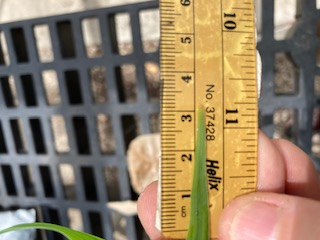

In [ ]:
# Build 300 inoculated leaves from 4 (hidden) virulence groups. y_true = class, which we pretend not to see.
rng = np.random.default_rng(42)
n = 75    # leaves per virulence group

# each group = (mean lesion mm, mean Fv/Fm, lesion sd, Fv/Fm sd);  more virulent -> longer lesion, lower Fv/Fm
specs = [( 10, 0.80, 4, 0.020),
         ( 60, 0.71, 6, 0.025),
         (110, 0.61, 6, 0.025),
         (175, 0.50, 7, 0.030)]

blocks, y_true = [], []
for grp, (lesion, fvfm, sl, sf) in enumerate(specs):
    blocks.append(np.column_stack([rng.normal(lesion, sl, n), rng.normal(fvfm, sf, n)]))
    y_true += [grp] * n
X = np.vstack(blocks)
X[:, 0] = X[:, 0].clip(0)          # lesion length cannot be negative
X[:, 1] = X[:, 1].clip(0, 0.85)    # Fv/Fm has a physiological ceiling near 0.83
y_true = np.array(y_true)

leaves = pd.DataFrame(X, columns=["lesion_length_mm", "fv_fm"])
print("Shape:", X.shape, " -> 300 inoculated leaves, 2 readouts each")
leaves.round(2).head()

Shape: (300, 2)  -> 300 inoculated leaves, 2 readouts each


,lesion_length_mm,fv_fm
0,11.22,0.81
1,5.84,0.79
2,13.00,0.80
3,13.76,0.81
4,2.20,0.79


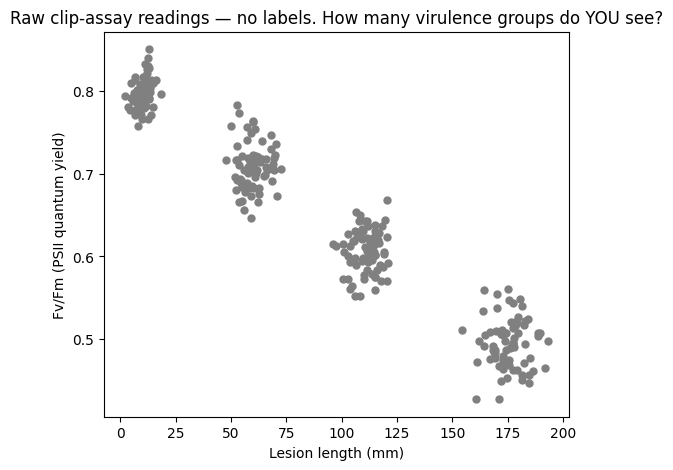

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=25, color="gray")
plt.title("Raw clip-assay readings — no labels. How many virulence groups do YOU see?")
plt.xlabel("Lesion length (mm)")
plt.ylabel("Fv/Fm (PSII quantum yield)")
plt.show()

Your eye probably sees ~4 clumps. A clustering algorithm makes that judgment mathematically —
and, crucially, keeps working in 10 or 100 dimensions where you simply **cannot** look.

## 2 · First, always scale your features. IMPORTANT!!

Clustering is based on **distance** between samples, and our two readouts live on **totally
different scales**: **lesion length** runs 0–~200 mm, but **Fv/Fm** runs only 0–1. Left as-is,
lesion length (big numbers) would dominate every distance and Fv/Fm would be almost ignored.
**Standardizing** puts every feature on equal footing: mean 0, standard deviation 1.

Rule of thumb: **scale before clustering** unless your features are already comparable.
`StandardScaler` does it in two lines.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # subtract mean, divide by std, per column

print("Before scaling — means:", X.mean(axis=0).round(2), " stds:", X.std(axis=0).round(2))
print("After  scaling — means:", X_scaled.mean(axis=0).round(2), " stds:", X_scaled.std(axis=0).round(2))

# We will use X_scaled from now on as good practice.

Before scaling — means: [89.1   0.65]  stds: [61.54  0.12]
After  scaling — means: [-0. -0.]  stds: [1. 1.]


## 3 · K-Means — the workhorse

**Idea (plain words):** you tell K-Means how many clusters you want, *k*. It then:
1. Drops *k* points ("centroids") at random.
2. Assigns every leaf to its **nearest** centroid.
3. Moves each centroid to the **average** of its assigned leaves.
4. Repeats 2–3 until the centroids stop moving.

| | |
|---|---|
| **✅ Advantages** | Very fast and scales to large datasets; simple to explain; works well when groups are roughly round and similar-sized. |
| **⚠️ Limitations** | You must choose *k* in advance; assumes round, equal-sized clusters (fails on elongated/curved shapes); forces every sample into a cluster (no outlier concept); sensitive to feature scaling and to the random start. |
| **🎯 Best applied when** | A quick first pass on a new plant-health dataset — e.g. sorting hundreds of isolates or leaves into a handful of morphologically compact groups, or as the baseline before trying anything fancier. |

Let's group the leaves into `k = 4` virulence groups.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)   # health-class cluster (0..3) for each leaf

print("First 20 cluster labels:", labels_km[:20])
print("Leaves per cluster:", np.bincount(labels_km))

First 20 cluster labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Leaves per cluster: [75 75 75 75]


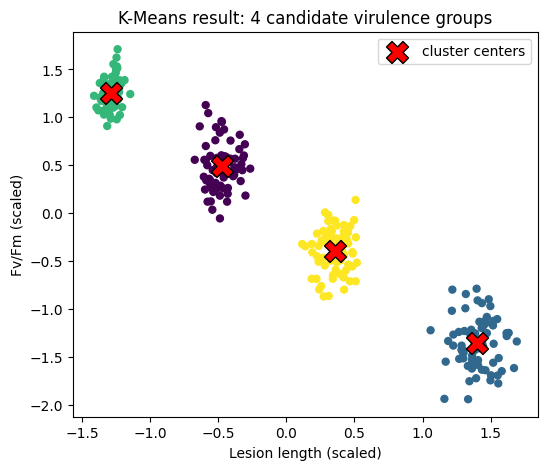

In [ ]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_km, cmap="viridis", s=25)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=250,
            edgecolor="black", label="cluster centers")
plt.title("K-Means result: 4 candidate virulence groups")
plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")
plt.legend(); plt.show()

Each color is a virulence group the algorithm discovered on its own; the red X's are the cluster
centers (the "average" leaf of each group). The label numbers 0–3 are arbitrary names —
cluster "2" is not more severe than cluster "0"; they're just tags.

### WHY SCALING IS IMPORTANT !!! LETS DO AN EXAMPLE!! See it for yourself — scaling changes the *result*, not the picture

Here's the subtle part: **the scatter looks the same before and after scaling** (matplotlib just
re-labels the axes), so scaling seems to do nothing. But clustering never looks at the picture —
it looks at **distances**, and scaling changes those. Watch it flip a K-Means result.

Mini-example: two virulence groups, each leaf measured two ways —
- **`bacterial_load`** (bacteria recovered, CFU): **huge** numbers that happen to **overlap** between
  the two groups (so, not informative here).
- **`fv_fm`**: **small** numbers (0–1) that **cleanly separate** the two groups.

In [ ]:
rng = np.random.default_rng(1); n = 100
bacterial_load = rng.normal(100000, 40000, 2*n).clip(0)                 # big numbers, OVERLAPPING
fvfm = np.concatenate([rng.normal(0.80, 0.02, n),
                       rng.normal(0.55, 0.02, n)]).clip(0, 0.85)    # small numbers, SEPARATING
demo = np.column_stack([bacterial_load, fvfm])
demo_true = np.array([0]*n + [1]*n)                                 # the real 2 groups

raw_labels    = KMeans(2, n_init=10, random_state=0).fit_predict(demo)                       # NO scaling
scaled_labels = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(demo))

print("ARI WITHOUT scaling:", round(adjusted_rand_score(demo_true, raw_labels), 3), " (0 = random -> wrong)")
print("ARI WITH    scaling:", round(adjusted_rand_score(demo_true, scaled_labels), 3), " (1 = perfect)")

ARI WITHOUT scaling: -0.004  (0 = random -> wrong)
ARI WITH    scaling: 1.0  (1 = perfect)


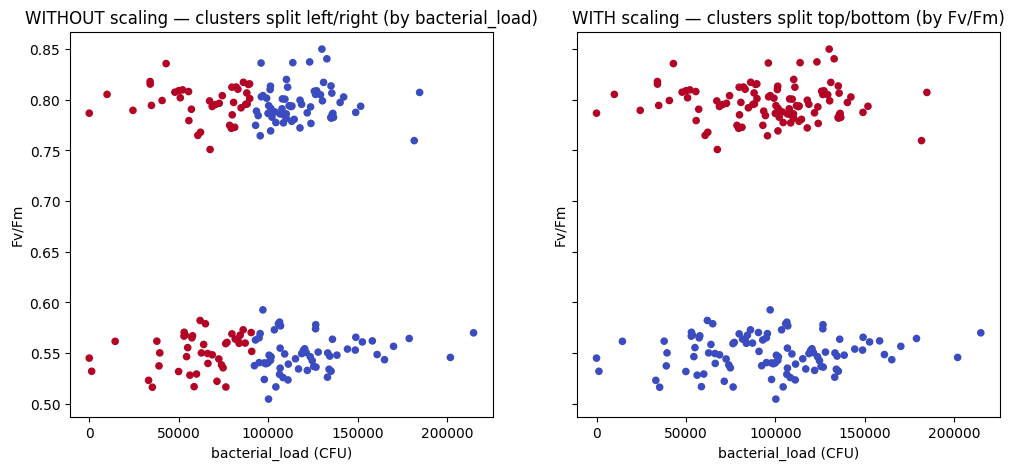

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax[0].scatter(demo[:,0], demo[:,1], c=raw_labels, cmap="coolwarm", s=20)
ax[0].set_title("WITHOUT scaling — clusters split left/right (by bacterial_load)")
ax[1].scatter(demo[:,0], demo[:,1], c=scaled_labels, cmap="coolwarm", s=20)
ax[1].set_title("WITH scaling — clusters split top/bottom (by Fv/Fm)")
for a in ax: a.set_xlabel("bacterial_load (CFU)"); a.set_ylabel("Fv/Fm")
plt.show()

**Same points in both panels — only the coloring (the clusters K-Means found) differs.** Without
scaling, the giant `bacterial_load` numbers dominate every distance, so K-Means slices the cloud
**left/right** by bacterial load and **ignores Fv/Fm entirely** — the true groups (top vs bottom) get
scrambled (ARI ≈ 0). After scaling, both features count equally and K-Means recovers the real
groups (ARI = 1). *That* is why we scale — even though the raw scatter looked perfectly fine.

Back to our clip-assay data: from here on we cluster **`X_scaled`**.

**In case later you can get the real groups**
The Adjusted Rand Index (ARI) is a metric used to evaluate the quality of a clustering model by measuring how similar its cluster assignments are to a set of true benchmark labels.

1.0: Perfect agreement between the clustering model and the true labels.

0.0: The clustering is purely random (no better than flipping a coin).

Negative: The clustering is worse than random, meaning the assignments are actively conflicting with the true structure.

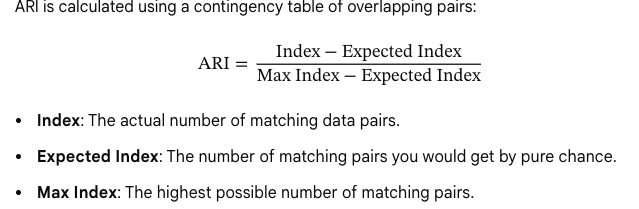

## 4 · How many virulence groups? Choosing *k*

Real data doesn't announce *k*. Two standard tools:

**(a) Elbow method.** For each *k*, K-Means reports **inertia** = total squared distance from
leaves to their centroid (lower = tighter clusters). Inertia always drops as *k* rises, but
the *improvement* flattens. The "elbow" — where extra clusters stop helping — is a good *k*.

**(b) Silhouette score.** Ranges −1 to +1; how well each leaf fits its own cluster vs the
nearest other cluster. **Higher is better.** Pick the *k* with the top score.

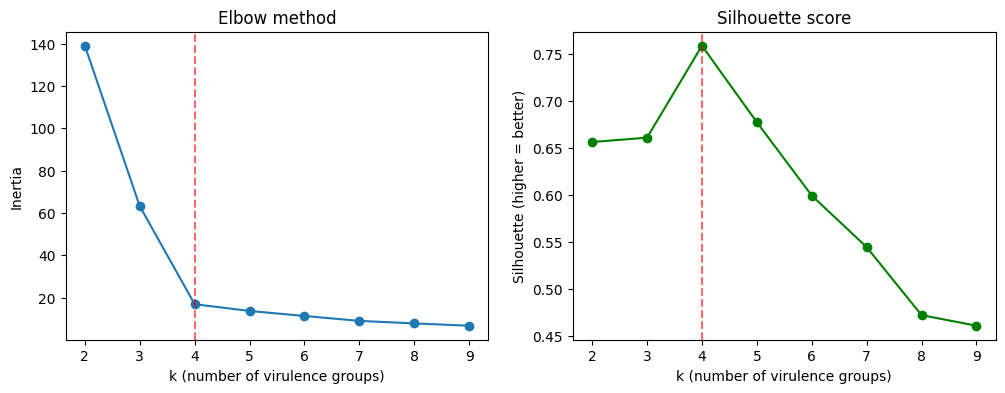

Best k by silhouette: 4


In [ ]:
ks = range(2, 10)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow method")
ax[0].set_xlabel("k (number of virulence groups)"); ax[0].set_ylabel("Inertia")
ax[0].axvline(4, color="red", ls="--", alpha=0.6)

ax[1].plot(list(ks), silhouettes, "o-", color="green"); ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k (number of virulence groups)"); ax[1].set_ylabel("Silhouette (higher = better)")
best_k = list(ks)[int(np.argmax(silhouettes))]
ax[1].axvline(best_k, color="red", ls="--", alpha=0.6)
plt.show()

print("Best k by silhouette:", best_k)

Both point to **k = 4** — the elbow bends there and the silhouette peaks there. In a real study
these two hints plus **domain knowledge** (what you know about the pathogen) guide the choice;
there is rarely one single "correct" *k*.

## 5 · Hierarchical (Agglomerative) clustering

**Idea:** start with every leaf as its own cluster, then repeatedly **merge the two closest
clusters** until all are joined. The merge history is a tree — a **dendrogram** — and you choose
the number of clusters *afterwards* by "cutting" it.

**Why plant scientists like this:** a dendrogram reads exactly like the **phylogenetic /
relatedness trees** you already use — leaves that join low are very similar; a tall branch
means a big morphological jump.

| | |
|---|---|
| **✅ Advantages** | No need to fix *k* beforehand — the dendrogram shows structure at every level; output is an intuitive tree, familiar to anyone who reads phylogenies; deterministic (no random start). |
| **⚠️ Limitations** | Slow and memory-heavy on large datasets (thousands+ of samples); merges are final — an early mistake can't be undone; the chosen linkage method (ward/average/…) changes the result. |
| **🎯 Best applied when** | Small-to-medium sample sets where relationships matter — e.g. relating a few dozen isolates or accessions, or exploring how pathotypes nest within one another, and you want a tree to show colleagues. |

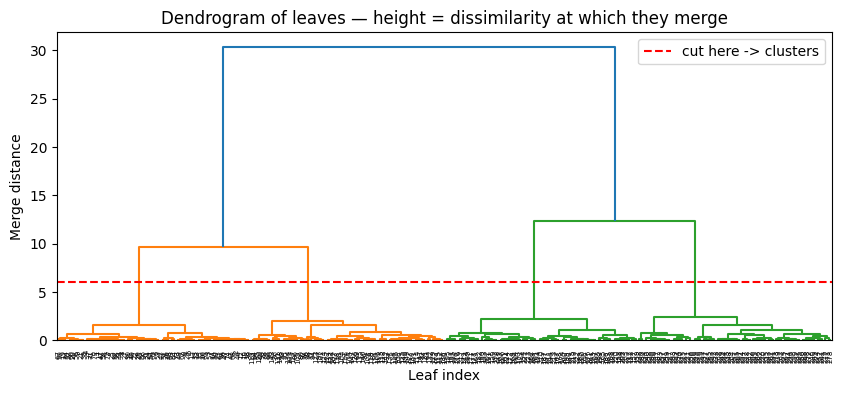

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X_scaled[:300]                       # 30 leaves for a legible tree
Z = linkage(sample, method="ward")           # ward = merge to keep clusters tight

plt.figure(figsize=(10, 4))
dendrogram(Z)
plt.title("Dendrogram of leaves — height = dissimilarity at which they merge")
plt.xlabel("Leaf index"); plt.ylabel("Merge distance")
plt.axhline(y=6, color="red", ls="--", label="cut here -> clusters")
plt.legend(); plt.show()

Cut horizontally (red line) and the number of vertical branches you cross is the number of
clusters. Lowering the cut splits finer virulence groups; raising it lumps them.

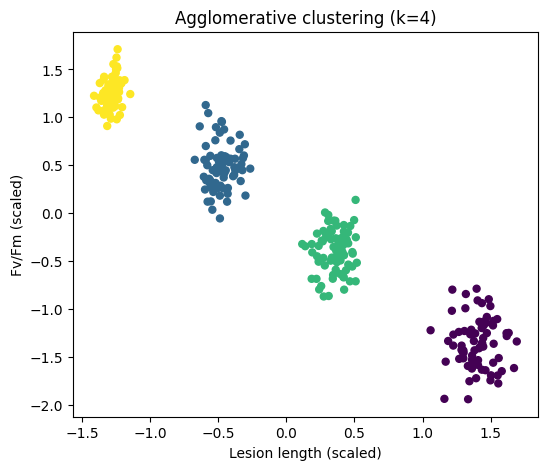

Silhouette: 0.759


In [ ]:
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg, cmap="viridis", s=25)
plt.title("Agglomerative clustering (k=4)")
plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")
plt.show()

print("Silhouette:", round(silhouette_score(X_scaled, labels_agg), 3))

**### You should consider using Hierarchical clustering instead of K-Means in several situations:**



* When you don't know the optimal
number of clusters (k) beforehand: Hierarchical clustering builds a complete hierarchy (a dendrogram) that allows you to determine the number of clusters after the clustering process by cutting the tree at different levels. K-Means, on the other hand, requires you to specify k in advance.
* When a tree-like structure (dendrogram) is important for understanding relationships: If you want to visualize the nested relationships between data points and clusters, similar to a phylogenetic tree, Hierarchical clustering is ideal. This is particularly useful in fields like biology (as mentioned in the notebook for plant scientists).
* For small to medium-sized datasets: Hierarchical clustering can be computationally more expensive and memory-intensive (O(n^3) for time, O(n^2) for memory) than K-Means (O(nkdi) where n is data points, k is clusters, d is dimensions, i is iterations). So, for very large datasets, K-Means is generally preferred for its speed.
* When clusters are not necessarily spherical or equal-sized: While K-Means assumes spherical, equally-sized clusters, Hierarchical clustering can be more flexible and discover clusters of various shapes, depending on the linkage method used.
* When you need deterministic results: Hierarchical clustering is deterministic (given the same parameters, it will always produce the same result), whereas K-Means can be sensitive to the initial random placement of centroids, requiring multiple runs (n_init) to find a good solution.

## 6 · DBSCAN — density-based, finds shapes and outliers

K-Means insists on round groups and forces **every** sample into a cluster. Biology is messier.
**DBSCAN** sees a cluster as a **dense region** of points; samples in sparse regions are labeled
**noise / outliers** (cluster `-1`) — perfect for **quality control** and **novel-strain hunting**.

Two knobs:
- **`eps`** — how close counts as a "neighbor" (the radius).
- **`min_samples`** — how many neighbors a point needs to sit in a dense core.

| | |
|---|---|
| **✅ Advantages** | Finds clusters of **any shape**; you don't specify the number of clusters; automatically labels **outliers/noise** (great for QC and novel-strain detection); robust to weird geometry. |
| **⚠️ Limitations** | Results hinge on `eps` (hard to tune); struggles when clusters have very different densities; degrades in very high dimensions where "distance" loses meaning. |
| **🎯 Best applied when** | Noisy, irregular data where you care about outliers — e.g. spotting an isolate that fits **no** known pathotype (possible new strain), cleaning bad measurements, or clusters that form curved bands rather than blobs. |

### A plant-health scenario where K-Means fails
Lets say that in a **field trial**, the disease spreads outward from a few infection foci, so the **infected
corn plants** trace **curved, interlocking fronts** across the plot rather than round patches. If
we map each infected plant by its **position in the field** (two spatial coordinates), those
fronts are exactly the non-round shape K-Means gets wrong — and DBSCAN gets right. We mimic two
such infection fronts below.

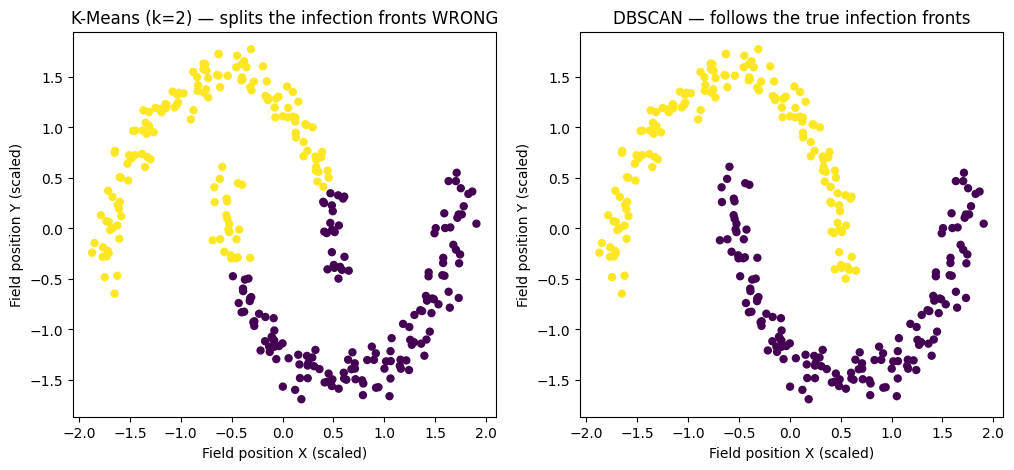

DBSCAN found clusters: {np.int64(0), np.int64(1)}   (-1 = noise/outliers)


In [ ]:
X_bands, _ = make_moons(n_samples=300, noise=0.06, random_state=42)   # two curved infection fronts
X_bands = StandardScaler().fit_transform(X_bands)                     # x,y = plant position in the plot

km_bands  = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_bands)
db_bands  = DBSCAN(eps=0.3, min_samples=5).fit_predict(X_bands)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_bands[:, 0], X_bands[:, 1], c=km_bands, cmap="viridis", s=25)
ax[0].set_title("K-Means (k=2) — splits the infection fronts WRONG")
ax[1].scatter(X_bands[:, 0], X_bands[:, 1], c=db_bands, cmap="viridis", s=25)
ax[1].set_title("DBSCAN — follows the true infection fronts")
for a in ax: a.set_xlabel("Field position X (scaled)"); a.set_ylabel("Field position Y (scaled)")
plt.show()

print("DBSCAN found clusters:", set(db_bands), "  (-1 = noise/outliers)")

K-Means slices the two fronts straight down the middle because it only knows circles. DBSCAN
follows the density and recovers the true shapes — and any stray infected plants become noise
(`-1`), which in practice you'd re-inspect (perhaps an independent introduction, not part of a front).

**Tip for `eps`:** too small → everything is noise; too large → everything becomes one cluster.
Try a few values and look at the result.

## 7 · Gaussian Mixture Models (GMM) — soft, probabilistic clusters

K-Means gives a **hard** answer: leaf *i* is in cluster 2, full stop. A **GMM** models the
data as a blend of bell-curves and gives each sample a **probability** of belonging to each
cluster — a **soft** assignment — and allows **stretched/elliptical** clusters.

**Why this is useful in plant pathology:** a leaf showing **mixed symptoms** might be 60% one
disease and 40% another. GMM captures that ambiguity instead of forcing a single call — exactly
the samples you'd want to send for expert review or lab confirmation.

| | |
|---|---|
| **✅ Advantages** | Gives **soft** probabilities, not just hard labels (captures ambiguous samples); handles **elliptical/stretched** clusters that K-Means can't; grounded in probability theory. |
| **⚠️ Limitations** | You still choose the number of components; can overfit or land in a poor solution; needs enough samples per component; assumes each cluster is roughly Gaussian (bell-shaped). |
| **🎯 Best applied when** | Clusters **overlap** and you need the uncertainty — e.g. a **mixed-symptom leaf** that is partly one disease and partly another, so you can flag borderline cases for lab confirmation instead of forcing a single call. |

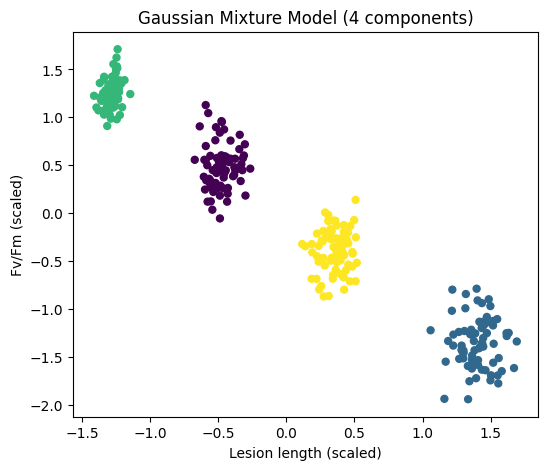

Membership probabilities (rows=leaves, cols=clusters):
[[0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]]


In [ ]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)              # hard label (most likely cluster)
proba      = gmm.predict_proba(X_scaled)         # soft: probability per cluster

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm, cmap="viridis", s=25)
plt.title("Gaussian Mixture Model (4 components)")
plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")
plt.show()

print("Membership probabilities (rows=leaves, cols=clusters):")
print(np.round(proba[:15], 2))

Each row sums to 1. A leaf between two virulence groups might read `[0.55, 0.45, 0, 0]` —
genuinely uncertain. That nuance is lost in K-Means and is often exactly what you want to flag.

## 8 · Seeing high-dimensional data with PCA

So far we used 2 features so we could plot directly. Real plant-health datasets have **many**
features — lesion length, % diseased area, SPAD, hyperspectral index, Fv/Fm, dozens of image or
gene-expression values. You can't plot 30 dimensions.

**PCA (Principal Component Analysis)** compresses many features into a few "principal
components" that retain as much variation as possible — usually we keep 2 for a scatter plot.
PCA is itself an unsupervised method (dimensionality reduction). Standard workflow:
**scale → cluster → PCA to 2-D for the picture.** We use it in the case study next.

| | |
|---|---|
| **✅ Advantages** | Turns many features into a 2-D picture you can actually read; removes redundancy between correlated measurements; fast; can speed up and de-noise clustering. |
| **⚠️ Limitations** | Components are **combinations** of features, so axes lose direct biological meaning; only captures **linear** structure (t-SNE/UMAP handle curved structure better for visualization); can hide small clusters. |
| **🎯 Best applied when** | You have **many** measurements (morphology panels, image features, gene-expression) and need to visualize or compress them before/after clustering. |

## 9 · Case study — profiling strains with five instruments

Now the realistic, multi-feature version. We phenotyped **240 inoculated corn leaves** from a
panel of *C. nebraskensis* strains, this time with **five** measurements spanning the modern
plant-health toolkit:

| Feature | Instrument / method | What it captures |
|---------|---------------------|------------------|
| `lesion_length_mm`   | ruler / clip assay              | visible symptom severity |
| `diseased_area_pct`  | digital image analysis (ImageJ) | % of leaf area diseased |
| `spad_chlorophyll`   | SPAD chlorophyll meter          | chlorophyll content (drops with infection) |
| `hyperspectral_di`   | hyperspectral imaging           | disease index; catches pre-symptomatic breakdown |
| `fv_fm`              | chlorophyll fluorescence        | PSII quantum yield (photosynthetic function) |

The leaves truly come from three virulence groups — **Weak**, **Moderate**, and **High** — but
imagine they arrived **unlabeled**. We'll cluster on the five measurements alone, then, because we
*do* know the true group here, **check whether the clusters match reality** — the honest way to
build trust in a method before using it on data that has no labels.

In [ ]:
# --- Build the strain-phenotyping dataset (synthetic but biologically plausible) ---
rng = np.random.default_rng(0)
n = 80  # inoculated leaves per virulence group

def strain(lesion, area, spad, hdi, fvfm):
    """Draw n leaves around typical values for one virulence group."""
    return pd.DataFrame({
        "lesion_length_mm":  rng.normal(lesion, lesion*0.18 + 2, n).clip(0),
        "diseased_area_pct": rng.normal(area,   6,    n).clip(0, 100),
        "spad_chlorophyll":  rng.normal(spad,   3,    n).clip(0),
        "hyperspectral_di":  rng.normal(hdi,    0.06, n).clip(0, 1),
        "fv_fm":             rng.normal(fvfm,   0.03, n).clip(0, 0.85),
    })

#                   lesion area spad  hdi  fvfm
weak     = strain(    30,  12,  50, 0.15, 0.80)   # short lesions, green, healthy PSII
moderate = strain(    95,  38,  37, 0.45, 0.68)
high     = strain(   165,  72,  25, 0.75, 0.52)   # long lesions, chlorotic, PSII damaged

survey = pd.concat([weak, moderate, high], ignore_index=True)
true_group  = np.array([0]*n + [1]*n + [2]*n)            # 0=Weak 1=Moderate 2=High (HELD OUT)
group_names = np.array(["Weak", "Moderate", "High"])
Xs_raw = survey.to_numpy()
print("Dataset shape:", survey.shape)
survey.describe().round(1)

Dataset shape: (240, 5)


,lesion_length_mm,diseased_area_pct,spad_chlorophyll,hyperspectral_di,fv_fm
count,240.0,240.0,240.0,240.0,240.0
mean,97.4,40.2,37.0,0.5,0.7
std,58.1,24.9,10.8,0.3,0.1
min,12.8,0.0,17.0,0.0,0.4
25%,35.6,15.8,26.1,0.2,0.5
50%,94.2,38.6,36.9,0.5,0.7
75%,149.8,66.9,47.7,0.7,0.8
max,235.6,86.9,59.2,0.9,0.8


In [ ]:
# 1) SCALE the five features (essential — mm, %, SPAD units, an index, and a ratio are all different scales)
Xs = StandardScaler().fit_transform(Xs_raw)

# 2) CLUSTER with K-Means, asking for 3 groups (we do NOT pass the true labels!)
survey_km = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(Xs)

# 3) COMPRESS 5 features -> 2 with PCA, just so we can plot
Xs_2d = PCA(n_components=2).fit_transform(Xs)

### PCA without cluster labels

To better understand PCA's role, here is the same PCA plot without any cluster labels applied. The points are shown in a single color, reflecting only their position in the reduced 2-dimensional space, independent of any clustering results. As you can see, without colors, it's much harder to discern distinct groups.

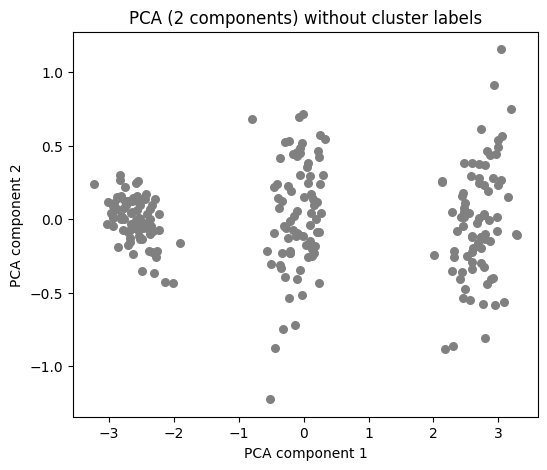

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], s=30, color='gray') # Plotting without 'c' argument for coloring
plt.title("PCA (2 components) without cluster labels")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

### PCA plot colored by K-Means discovered clusters

Now that PCA has given us a 2D view of the data, we can use the labels from K-Means to color these points. Each color represents a group that K-Means found. Remember, K-Means simply assigns numbers (like 0, 1, 2) to its clusters. These numbers are arbitrary, so the colors chosen for them by the plot are also arbitrary. This plot helps us see if the clusters K-Means found are visually distinct in this simplified 2D space.

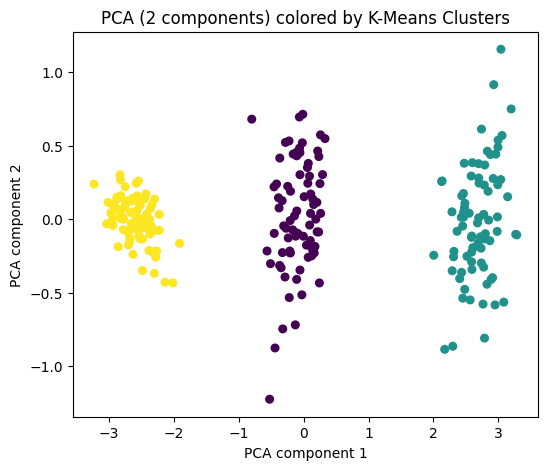

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], c=survey_km, cmap="viridis", s=30)
plt.title("PCA (2 components) colored by K-Means Clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

### PCA plot colored by the TRUE virulence groups

For comparison, here is the exact same PCA plot, but this time we'll color the points based on their *actual*, known virulence groups (`true_group`). This is what the groups *really* look like. By comparing this to the K-Means colored plot, we can see how well K-Means did at finding these true groups, even if the specific colors don't match up perfectly (because K-Means labels are arbitrary).

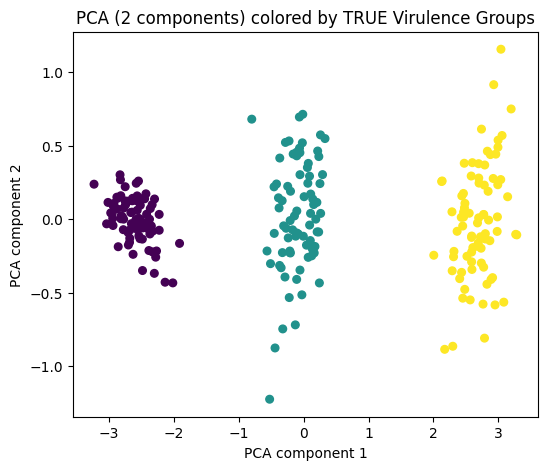

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], c=true_group, cmap="viridis", s=30)
plt.title("PCA (2 components) colored by TRUE Virulence Groups")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

### PCA plot with K-Means labels re-mapped to match True Group colors

To visually confirm that K-Means successfully identified the same groupings as the true virulence groups, we can re-map the arbitrary integer labels assigned by K-Means (`survey_km`) to align with the labels of the `true_group`. This plot uses the K-Means clusters, but with colors assigned to visually match the 'true' labels. This should look very similar, if not identical, to the plot colored by `true_group`.

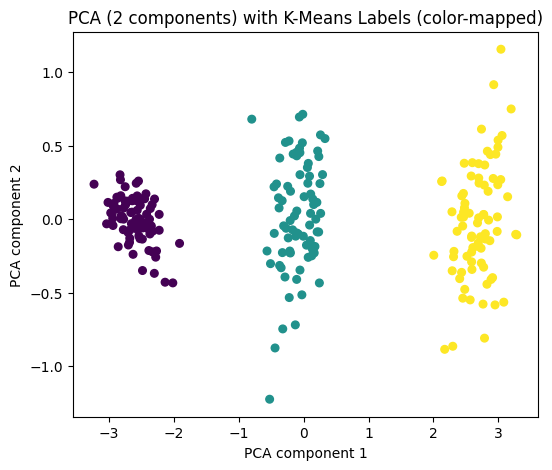

In [ ]:
# Create a re-mapping of K-Means labels to align with true_group colors
# Based on the crosstab in cell Yu9qJ0V1xoJo:
# K-Means cluster 0 corresponds to true_group 1 ('Moderate')
# K-Means cluster 1 corresponds to true_group 2 ('High')
# K-Means cluster 2 corresponds to true_group 0 ('Weak')

survey_km_remapped = np.zeros_like(survey_km)
survey_km_remapped[survey_km == 0] = 1 # K-Means 0 (Moderate) gets true_group's Moderate color (1)
survey_km_remapped[survey_km == 1] = 2 # K-Means 1 (High) gets true_group's High color (2)
survey_km_remapped[survey_km == 2] = 0 # K-Means 2 (Weak) gets true_group's Weak color (0)

plt.figure(figsize=(6, 5))
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], c=survey_km_remapped, cmap="viridis", s=30)
plt.title("PCA (2 components) with K-Means Labels (color-mapped)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

The two pictures line up closely — K-Means recovered the three virulence groups from the five
instrument readouts alone, **without ever seeing a label**. Weak strains sit far from the
aggressive ones, with Moderate bridging them.

## 10 · Which algorithm should I use?

| Algorithm | Pick *k* first? | Cluster shape | Finds outliers? | Best for (plant-health) |
|-----------|:---:|-----------|:---:|----------|
| **K-Means** | Yes | Round, similar size | No | Fast first pass on isolates/leaves; big datasets |
| **Hierarchical** | No* | Flexible | No | Few–medium samples; want a phylogeny-like tree |
| **DBSCAN** | No | Any shape | **Yes** | Field-map shapes, noisy data, novel-strain / QC outliers |
| **GMM** | Yes | Elliptical | No | Mixed-symptom leaves; want soft probabilities |

*Hierarchical builds the whole tree; you choose the number of clusters by cutting it afterward.

**Practical workflow for your projects:**
1. **Always scale** your measurements first.
2. Start with **K-Means** + elbow/silhouette to get a feel for how many groups exist.
3. If groups look non-round or you need outliers, try **DBSCAN**.
4. If you want a tree or have few samples, use **Hierarchical**.
5. If memberships are fuzzy/overlapping, use **GMM**.
6. Use **PCA** to visualize, describe each cluster's **feature profile**, and sanity-check
   against **domain knowledge**.
7. If your data mixes **numbers and categories**, don't use K-Means

---

## 12 · ✏️ Exercises

Try these yourself; solutions are in the last section.

**Ex 1.** Re-run K-Means on the **clip-assay** data `X_scaled` (lesion length × Fv/Fm) with **k = 3**
instead of 4. Plot the
result and print the silhouette score. Is it higher or lower than k = 4?

**Ex 2.** Change DBSCAN's `eps` on the field-map data `X_bands` (infection fronts) to **0.15**, then **0.6**. What
happens to the number of clusters and the amount of noise (`-1`)?

In [ ]:
# Ex 1 — your code here


In [ ]:
# Ex 2 — your code here


## 14 · ✅ Solutions

Try first, then run these to check.

In [ ]:
# --- Ex 1: K-Means with k=3 on clip-assay data (lesion x Fv/Fm) ---
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=km3, cmap="viridis", s=25)
plt.title("K-Means k=3"); plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")
plt.show()
print("Silhouette k=3:", round(silhouette_score(X_scaled, km3), 3))
print("Silhouette k=4:", round(silhouette_score(X_scaled,
      KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)), 3))
print("-> k=4 scores higher because the leaves truly form 4 virulence groups.")

In [ ]:
# --- Ex 2: DBSCAN eps sensitivity on the field map (infection fronts) ---
for e in [0.15, 0.3, 0.6]:
    lab = DBSCAN(eps=e, min_samples=5).fit_predict(X_bands)
    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())
    print(f"eps={e}: clusters={n_clusters}, noise points={n_noise}")
print("-> small eps: almost everything becomes noise; large eps: the two fronts merge into one.")

---
## 🎉 Wrap-up

You now know the core of unsupervised clustering, in a plant-health context:

- **Scale first**, because clustering is about distance and plant data mixes many units.
- **K-Means** for a fast, round-group first pass; use the **elbow** + **silhouette** to pick *k*.
- **Hierarchical** when you want a **dendrogram** (a tree, like a phylogeny) and no fixed *k*.
- **DBSCAN** for **odd shapes and outliers** — novel-strain hunting and QC.
- **GMM** for **soft, overlapping** memberships (mixed-symptom samples).
- **PCA** to **see** clusters that live in many measurements.
- Validate with the **silhouette score**, cluster **feature profiles**, and, above all,
  **biological sense**.

**Next step:** with these tools you can group unlabeled leaf images, strain phenotypes, or
pathogen genotypes.